In [40]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True
})

# Dry Setteling and Overburden (For HS2SWE)

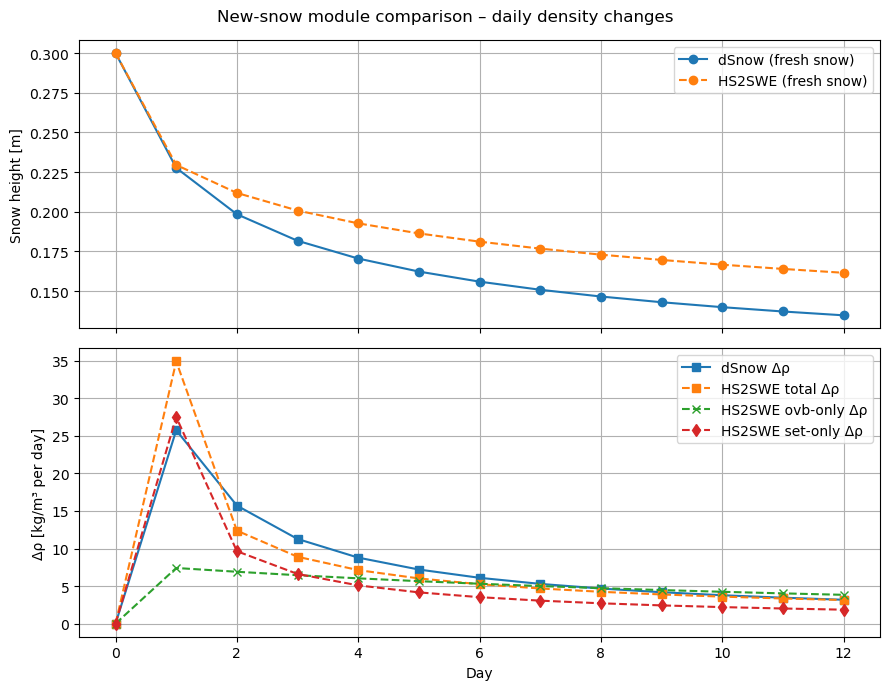

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) SETUP: experiment definition
# ============================================================

days = 12
dt = 86400.0  # [s]

h0 = 0.30
rho0_dsnow = 81.0
rho0_hs2swe = 113.7

swe_dsnow = h0 * rho0_dsnow
swe_hs2swe = h0 * rho0_hs2swe

ovb = 0.30 * 120.0  # [kg/m^2]
g = 9.81

days_axis = np.arange(days + 1)

# ============================================================
# 2) MODEL PARAMETERS
# ============================================================

# dSnow / Winkler
eta0 = 8.52e6
k_w = 0.0299
rho_max_w = 401.3

# HS2SWE
eta_h = 6.051e7
rho_max_h = 571.6
rho_new = rho0_hs2swe

c1, c2, c3, c4, c5 = 2.8e-6, 0.042, 0.046, 0.081, 0.018
T = 0.0

# ============================================================
# 3) STORAGE
# ============================================================

h_w = [h0]
rho_w = [rho0_dsnow]
delta_rho_w = [0.0]

h_h = [h0]
rho_h = [rho0_hs2swe]
rho_h_ovb = [rho0_hs2swe]
rho_h_set = [rho0_hs2swe]

delta_rho_h = [0.0]
delta_rho_h_ovb = [0.0]
delta_rho_h_set = [0.0]

# ============================================================
# 4) TIME INTEGRATION
# ============================================================

for _ in range(days):

    # --------------------------------------------------------
    # 4A) dSnow new-snow densification
    # --------------------------------------------------------
    rho_prev = rho_w[-1]
    h_prev = h_w[-1]

    eta_eff = eta0 * np.exp(k_w * rho_prev)
    h_new = h_prev / (1.0 + dt * (ovb * g) / eta_eff)
    rho_new_w = swe_dsnow / h_new

    if rho_new_w > rho_max_w:
        rho_new_w = rho_max_w
        h_new = swe_dsnow / rho_max_w

    h_w.append(h_new)
    rho_w.append(rho_new_w)
    delta_rho_w.append(rho_new_w - rho_prev)

    # --------------------------------------------------------
    # 4B) HS2SWE new-snow densification
    # --------------------------------------------------------
    rho_prev = rho_h[-1]

    term_ovb = (ovb * g) / (eta_h * np.exp(c4 * T + c5 * rho_prev))
    term_set = c1 * np.exp(-c2 * T - c3 * max(0.0, rho_prev - rho_new))
    rho_dot = term_ovb + term_set

    rho_new_tot = min(rho_prev + rho_prev * dt * rho_dot, rho_max_h)

    h_prev = h_h[-1]
    h_new = h_prev * (rho_prev / rho_new_tot)

    rho_h.append(rho_new_tot)
    h_h.append(h_new)
    delta_rho_h.append(rho_new_tot - rho_prev)

    # --- overburden only
    rho_prev_ovb = rho_h_ovb[-1]
    rho_new_ovb = min(
        rho_prev_ovb + rho_prev_ovb * dt *
        (ovb * g) / (eta_h * np.exp(c4 * T + c5 * rho_prev_ovb)),
        rho_max_h
    )
    rho_h_ovb.append(rho_new_ovb)
    delta_rho_h_ovb.append(rho_new_ovb - rho_prev_ovb)

    # --- settling only
    rho_prev_set = rho_h_set[-1]
    rho_new_set = min(
        rho_prev_set + rho_prev_set * dt *
        c1 * np.exp(-c2 * T - c3 * max(0.0, rho_prev_set - rho_new)),
        rho_max_h
    )
    rho_h_set.append(rho_new_set)
    delta_rho_h_set.append(rho_new_set - rho_prev_set)

# Convert to arrays
h_w = np.array(h_w)
h_h = np.array(h_h)

delta_rho_w = np.array(delta_rho_w)
delta_rho_h = np.array(delta_rho_h)
delta_rho_h_ovb = np.array(delta_rho_h_ovb)
delta_rho_h_set = np.array(delta_rho_h_set)

# ============================================================
# 5) PLOTTING
# ============================================================

fig, (ax_h, ax_drho) = plt.subplots(
    2, 1, sharex=True, figsize=(9, 7)
)

# --- Snow height
ax_h.plot(days_axis, h_w, "o-", label="dSnow (fresh snow)")
ax_h.plot(days_axis, h_h, "o--", label="HS2SWE (fresh snow)")
ax_h.set_ylabel("Snow height [m]")
ax_h.legend()
ax_h.grid(True)

# --- Density DIFFERENCE
ax_drho.plot(days_axis, delta_rho_w, "s-", label="dSnow Δρ")
ax_drho.plot(days_axis, delta_rho_h, "s--", label="HS2SWE total Δρ")
ax_drho.plot(days_axis, delta_rho_h_ovb, "x--", label="HS2SWE ovb-only Δρ")
ax_drho.plot(days_axis, delta_rho_h_set, "d--", label="HS2SWE set-only Δρ")
ax_drho.set_xlabel("Day")
ax_drho.set_ylabel("Δρ [kg/m³ per day]")
ax_drho.legend()
ax_drho.grid(True)

plt.suptitle("New-snow module comparison – daily density changes")
plt.tight_layout()
plt.show()

## Check d Snow components

In [ ]:
# eta0 * np.exp(k * rho)

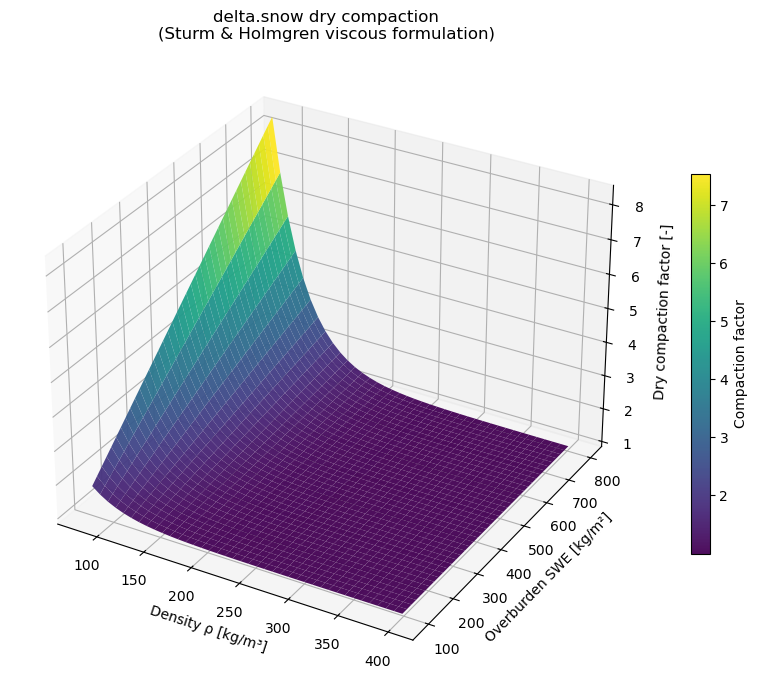

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# PARAMETERS
# ============================================================

k = 0.029297
eta0 = 8_543_502.0
g = 9.81
dt = 86400.0  # one day [s]

# parameter ranges
SWE_SUM = np.linspace(90, 800, 40)     # [kg/m^2] overburden SWE
rho = np.linspace(81, 401, 40)         # [kg/m^3] layer density

# ============================================================
# MESHGRID
# ============================================================

RHO, SWE_OVB = np.meshgrid(rho, SWE_SUM)

# ============================================================
# DRY COMPACTION PHYSICS
# ============================================================

eta_term = eta0 * np.exp(k * RHO)
overburden_force = g * SWE_OVB

dry_compaction = 1.0 + dt * (overburden_force / eta_term)

# ============================================================
# 3D PLOT
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    RHO,
    SWE_OVB,
    dry_compaction,
    cmap="viridis",
    edgecolor="none",
    alpha=0.95
)

ax.set_xlabel("Density ρ [kg/m³]")
ax.set_ylabel("Overburden SWE [kg/m²]")
ax.set_zlabel("Dry compaction factor [-]")

ax.set_title("delta.snow dry compaction\n(Sturm & Holmgren viscous formulation)")

fig.colorbar(surf, shrink=0.6, label="Compaction factor")
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# PARAMETERS (HS2SWE)
# ============================================================

g = 9.81
dt = 86400.0

eta_h = 6.051e7
c4 = 0.081
c5 = 0.018
T = 0.0  # constant temperature

# parameter ranges
SWE_SUM = np.linspace(90, 800, 40)     # [kg/m^2]
rho = np.linspace(81, 401, 40)         # [kg/m^3]

# ============================================================
# MESHGRID
# ============================================================

RHO, SWE_OVB = np.meshgrid(rho, SWE_SUM)

# ============================================================
# HS2SWE OVERBURDEN DENSIFICATION
# ============================================================

rho_dot_ovb = (
    (g * SWE_OVB) /
    (eta_h * np.exp(c4 * T + c5 * RHO))
)

# height-compaction-equivalent factor
hs2swe_compaction_ovb = 1.0 + dt * rho_dot_ovb

# ============================================================
# 3D PLOT
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    RHO,
    SWE_OVB,
    hs2swe_compaction_ovb,
    cmap="plasma",
    edgecolor="none",
    alpha=0.95
)

ax.set_xlabel("Density ρ [kg/m³]")
ax.set_ylabel("Overburden SWE [kg/m²]")
ax.set_zlabel("Compaction factor [-]")

ax.set_title("HS2SWE overburden compaction\n(density-rate formulation)")

fig.colorbar(surf, shrink=0.6, label="Compaction factor")
plt.tight_layout()
plt.show()

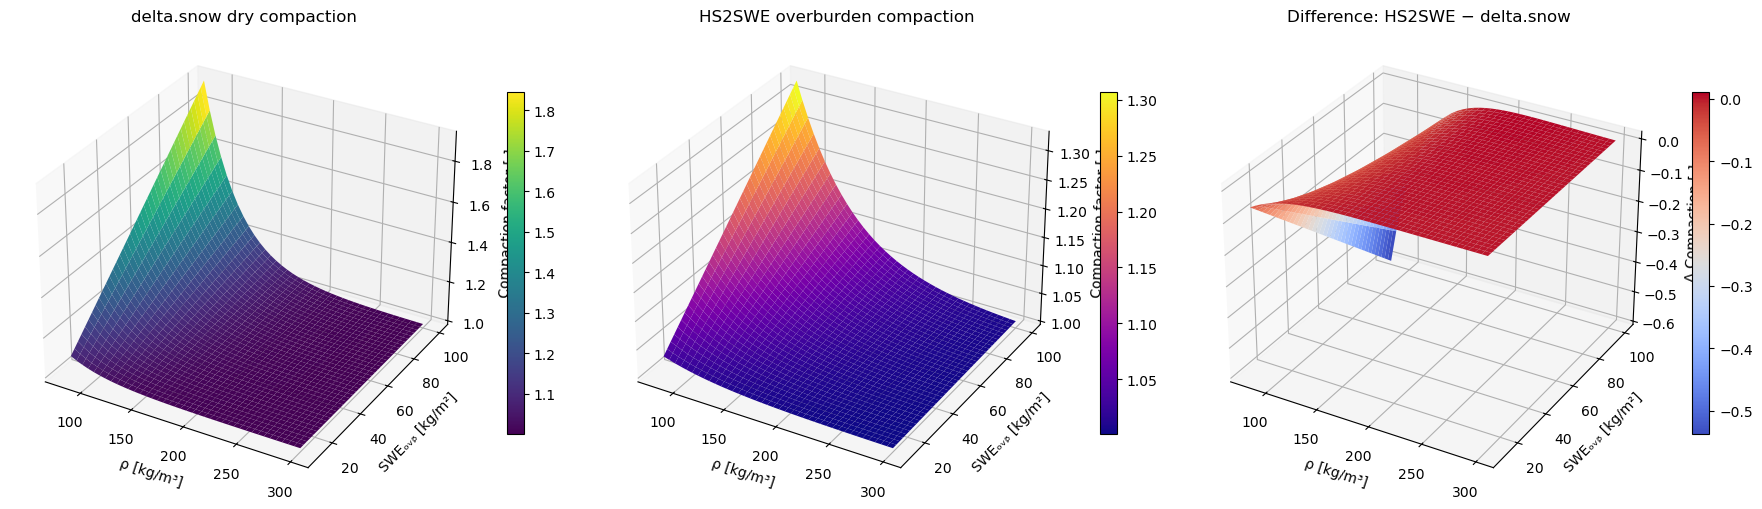

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# COMMON GRID
# ============================================================

SWE_SUM = np.linspace(10, 100, 40)     # [kg/m^2] 100 would alreeday be a larger events wehen look ing at the NW data
rho = np.linspace(81, 300, 40)         # [kg/m^3] not much densification when 300 is exceeded

RHO, SWE_OVB = np.meshgrid(rho, SWE_SUM)

g = 9.81
dt = 86400.0

# ============================================================
# delta.snow (Winkler / Sturm–Holmgren)
# ============================================================

eta0 = 8_543_502.0
k = 0.029297

eta_term_dsnow = eta0 * np.exp(k * RHO)
C_dsnow = 1.0 + dt * (g * SWE_OVB / eta_term_dsnow)

# ============================================================
# HS2SWE (overburden-only)
# ============================================================

eta_h = 6.051e7
c4 = 0.081
c5 = 0.018
T = 0.0

eta_term_hs2swe = eta_h * np.exp(c4 * T + c5 * RHO)
C_hs2swe = 1.0 + dt * (g * SWE_OVB / eta_term_hs2swe)

# ============================================================
# DIFFERENCE
# ============================================================

C_diff = C_hs2swe - C_dsnow

# ============================================================
# 3D PLOTTING
# ============================================================

fig = plt.figure(figsize=(18, 6))

# --- delta.snow
ax1 = fig.add_subplot(131, projection="3d")
s1 = ax1.plot_surface(
    RHO, SWE_OVB, C_dsnow,
    cmap="viridis", edgecolor="none"
)
ax1.set_title("delta.snow dry compaction")
ax1.set_xlabel("ρ [kg/m³]")
ax1.set_ylabel("SWEₒᵥᵦ [kg/m²]")
ax1.set_zlabel("Compaction factor [-]")
fig.colorbar(s1, ax=ax1, shrink=0.6)

# --- HS2SWE
ax2 = fig.add_subplot(132, projection="3d")
s2 = ax2.plot_surface(
    RHO, SWE_OVB, C_hs2swe,
    cmap="plasma", edgecolor="none"
)
ax2.set_title("HS2SWE overburden compaction")
ax2.set_xlabel("ρ [kg/m³]")
ax2.set_ylabel("SWEₒᵥᵦ [kg/m²]")
ax2.set_zlabel("Compaction factor [-]")
fig.colorbar(s2, ax=ax2, shrink=0.6)

# --- Difference
ax3 = fig.add_subplot(133, projection="3d")
s3 = ax3.plot_surface(
    RHO, SWE_OVB, C_diff,
    cmap="coolwarm", edgecolor="none"
)
ax3.set_title("Difference: HS2SWE − delta.snow")
ax3.set_xlabel("ρ [kg/m³]")
ax3.set_ylabel("SWEₒᵥᵦ [kg/m²]")
ax3.set_zlabel("Δ Compaction [-]")
fig.colorbar(s3, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()